# Data Analytics and Exploratory Data Analysis

## Overview

Before Machine Lerning Models can be developed, the data should be properly cleaned, structiured and understood. In real world Data Science Projects, data preparation and data exploration often take majority of the work. In this phase I'll be working with two datasets, **Titanic Data** and **House Price Data** by performing data cleaning and EDA. The goal is to transform raw data into clean, reliable data while identifying meaningful patterns, relationship and trends that may influence future machine learning models.


### Importing Neccessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Part 1. Data Loading and Inspection

### Titanic data

In [ ]:
# Loading the titanic dataset
titanic_data=pd.read_csv("Datasets/Titanic-Dataset.csv")
titanic_data.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
print("Shape of the dataset:\n",titanic_data.shape)
print(f"\nColumns of the dataset:\n", titanic_data.columns)
print(f"\nData types of the dataset:\n",titanic_data.dtypes)


Shape of the dataset:
 (891, 12)

Columns of the dataset:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data types of the dataset:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
# statistical information of the dataset
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Checking for missing values
titanic_missing_values=titanic_data.isna().sum()
titanic_missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Some of the columns has got missing values, the Age, Cabin and Embarked. we will handle the missing values later.


In [ ]:
# Checking for the duplicated rows in the dataset
titanic_duplicated= titanic_data.duplicated().sum()
titanic_duplicated

0

The dataset has no duplicated rows

### Housing Dataset

In [ ]:
#load the housing data
housing_data=pd.read_csv("Datasets/Housing.csv")
housing_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
print("Shape of the dataset:\n",housing_data.shape)
print(f"\nColumns of the dataset:\n", housing_data.columns)
print(f"\nData types of the dataset:\n",housing_data.dtypes)


Shape of the dataset:
 (545, 13)

Columns of the dataset:
 Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Data types of the dataset:
 price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [ ]:
# statistical information of the dataset
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Checking for missing values
housing_missing_values=housing_data.isna().sum()
housing_missing_values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

The dataset has no missing values

In [ ]:
housing_duplicated=housing_data.duplicated().sum()
housing_duplicated

0

The dataset has no duplicated rows

## Dataset 1: Titanic Dataset(Survival Analysis)

### 1. Structure
* The dataset has 891 rows and 12 columns.
* Data types: the dataset have a mix of numerical and categorical features.
    - Interger/Float: PassengerId, Survived, Pclass, Age, SibSp, Parch, and Fare.
    - Categorical/Object: Name, Sex, Ticket, Cabin, and Embarked.

### Quality
* Missing values: the dataset has got three columns with missing values.
    - Age is missing 177 valus, which requires imputation strategy with either, mediian or mode. 
    - Cabin is missing 687 values (nearly 77% data loss), indicating it may need to be dropped or heavily engineered into a binary feature (Cabin recorded vs. unknown).   
    - Embarked is missing 2 rows, which can be safely filled using mode imputation.
* Duplicates: we have 0 duplicated row,confirming that there is unique passenger records.    

## Dataset 2: House Prices Dataset

### 1. Structure

* The dataset has 545 rows and 13 columns.
* Data Types: Composed of mixed numerical and binary/categorical features.
   - Integer/Float: price, area, bedrooms, bathrooms, stories, and parking.
   - Categorical/Object: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, and furnishingstatus.

### 2. Quality

* Missing Values: 0 missing values detected across all columns, making this an exceptionally clean, fully populated dataset.
* Duplicates: 0 duplicate rows detected, confirming that each property listing represents a unique entry.
* Cleaning Priorities: While data completeness is perfect, the next phase must focus on encoding the text fields (converting 'yes'/'no' answers into 1s and 0s) to prepare them for correlation metrics and exploratory visualization.




## Part 2: Data Cleaning

### Handling missing values for the titanic dataset

In [ ]:
titanic_missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Check original distribution to decide
print(titanic_data['Age'].skew())

#fill the Age column with median
titanic_data["Age"]=titanic_data["Age"].fillna(titanic_data["Age"].median())
# filling the Embarked column with mode
most_frequent=titanic_data['Embarked'].mode()[0]
titanic_data['Embarked']=titanic_data['Embarked'].fillna(most_frequent)
# dropping the cabin column
titanic_data=titanic_data.drop(columns=['Cabin'])



0.38910778230082704


In [ ]:
titanic_data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Titanic Data
* Since we had three columns with missing values; Age, Cabin and Embarked we had to handle the missing values with the appropriate method.
- Missing values treatment for **Age**: imputed missing values using **Median**. The age column has 177 rows with missing values which is a small percentage and therefore dropping the rows will reduce the data size. 
- Missing values treatment for the Embarked column: Missing values in the Embarked column were filled using the mode ('S') because it is a categorical feature with an extremely low missingness rate, allowing us to seamlessly complete the data without introducing structural bias
- Missing values treatment for the Cabin column: The Cabin column was dropped entirely because it had a large percentage of missing values, meaning any attempt to impute its missing values would introduce noise

* The titanic dataset had no duplicated rows
### Housing data
* The house prices data has no missing values and no duplicated rows as well.

### Correct Data Types

In [ ]:
titanic_data["Age"]=titanic_data['Age'].astype('int64')

# Convert Survived and Pclass to category types
titanic_data['Survived'] = titanic_data['Survived'].astype('category')

titanic_data['Pclass'] = titanic_data['Pclass'].astype('category')


In [ ]:
# Print the updated structure and summary
print("Titanic Dataset Data Types:")
print(titanic_data.dtypes)


Titanic Dataset Data Types:
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex              object
Age               int64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
dtype: object


In [ ]:
# List of core numeric columns
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for col in numeric_cols:
    housing_data[col] = pd.to_numeric(housing_data[col], errors='coerce')

# List of text-based categorical attributes
categorical_cols = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating', 
    'airconditioning', 'prefarea', 'furnishingstatus'
]

# Cast text features to explicit string/object type
for col in categorical_cols:
    housing_data[col] = housing_data[col].astype('object')



In [ ]:
# Print the updated structure and summary
print("House Prices Dataset Data Types:")
print(housing_data[numeric_cols + categorical_cols].dtypes)


House Prices Dataset Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
parking              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
prefarea            object
furnishingstatus    object
dtype: object


## Part 3: Exploratory Data Analysis (EDA)

### Univariate Analysis

--- Titanic Numerical Summary ---
              Age        Fare       SibSp       Parch
count  891.000000  891.000000  891.000000  891.000000
mean    29.345679   32.204208    0.523008    0.381594
std     13.028212   49.693429    1.102743    0.806057
min      0.000000    0.000000    0.000000    0.000000
25%     22.000000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     35.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000

--- Titanic Categorical Summary ---
        Survived  Pclass   Sex Embarked
count        891     891   891      891
unique         2       3     2        3
top            0       3  male        S
freq         549     491   577      646


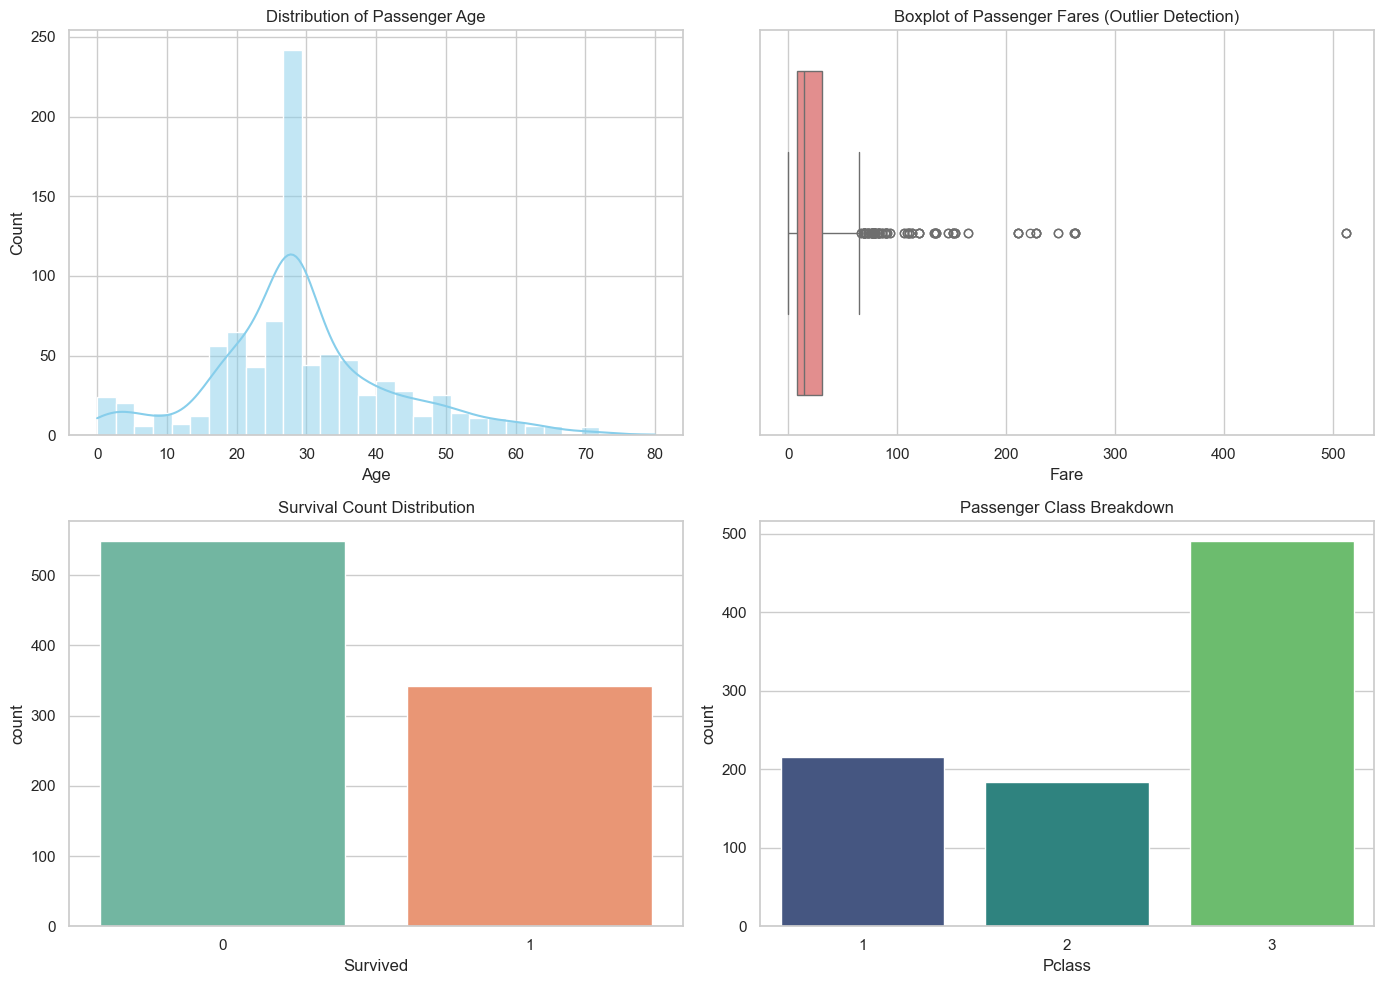

In [ ]:

# Set style for presentation-ready visuals
sns.set_theme(style="whitegrid")

# TITANIC DATASET DESCRIPTIVES
print("--- Titanic Numerical Summary ---")
print(titanic_data[['Age', 'Fare', 'SibSp', 'Parch']].describe())
print("\n--- Titanic Categorical Summary ---")
print(titanic_data[['Survived', 'Pclass', 'Sex', 'Embarked']].describe(include='all'))

# Plotting Titanic Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(titanic_data['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Passenger Age')

sns.boxplot(x=titanic_data['Fare'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Boxplot of Passenger Fares (Outlier Detection)')

sns.countplot(x='Survived', data=titanic_data, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Survival Count Distribution')

sns.countplot(x='Pclass', data=titanic_data, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Passenger Class Breakdown')
plt.tight_layout()
plt.show()



The above plots reveal that Passenger Fares exhibit the highest overall variation and contain severe right-side outliers, highlighted by an extreme luxury ticket priced over $500 that sits entirely isolated from the rest of the data. For Age, the distribution shows a balanced spread across generations, but features a massive, sharp spike just under 30 years old caused by filling the missing values with the median. Finally, when looking at the most frequent categories, the charts clearly show that the vast majority of passengers traveled in 3rd class (Class 3) and unfortunately did not survive (Status 0).





--- House Prices Numerical Summary ---
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


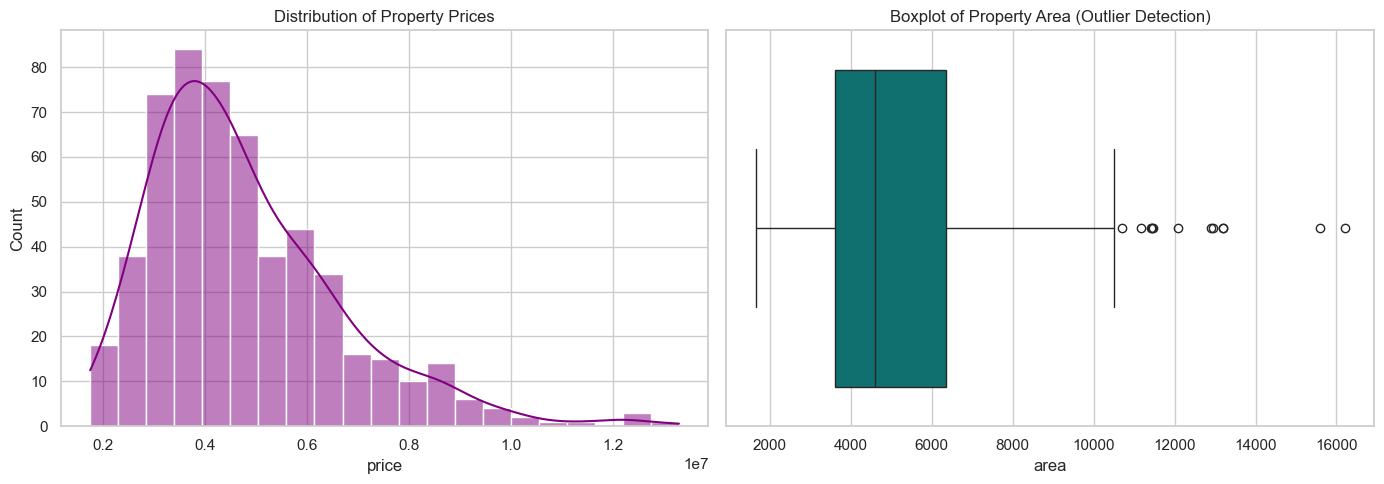

In [ ]:
# HOUSE PRICES DATASET DESCRIPTIVES
print("\n--- House Prices Numerical Summary ---")
print(housing_data[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']].describe())

# Plotting House Prices Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(housing_data['price'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Property Prices')

sns.boxplot(x=housing_data['area'], ax=axes[1], color='teal')
axes[1].set_title('Boxplot of Property Area (Outlier Detection)')
plt.tight_layout()
plt.show()


The charts show that Property Prices have high variation and a distinct right skew, with most homes clustered affordably between 3 and 5 million while a long tail of luxury estates stretches past 12 million. Similarly, the Property Area features several clear outliers on the right side, showing a handful of exceptionally large properties stretching up to 16,000 square feet well beyond the typical neighborhood average of 4,000 to 6,000 square feet. Together, these plots prove that both price and size are pulled upward by a small group of premium, high-end listings.



### Bivariate analysis

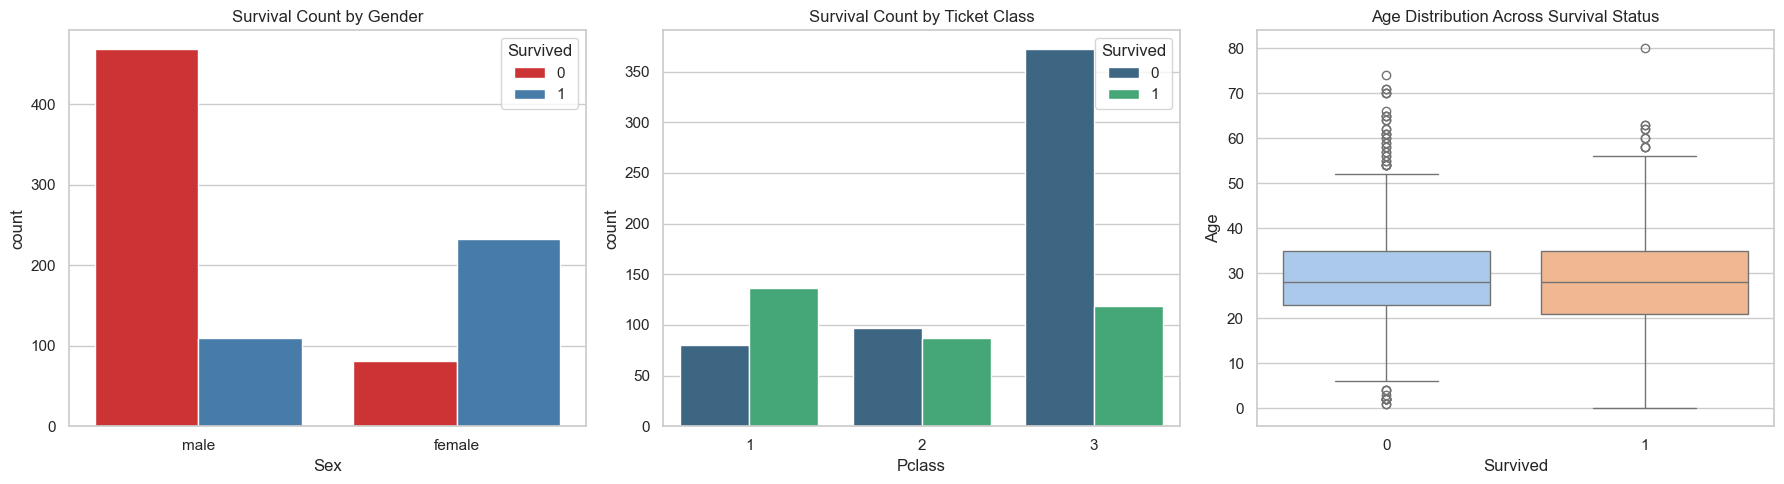

In [ ]:
# TITANIC BIVARIATE PLOTS 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Survival vs Gender
sns.countplot(x='Sex', hue='Survived', data=titanic_data, ax=axes[0], palette='Set1')
axes[0].set_title('Survival Count by Gender')

# 2. Survival vs Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=titanic_data, ax=axes[1], palette='viridis')
axes[1].set_title('Survival Count by Ticket Class')

# 3. Age vs Survival
sns.boxplot(x='Survived', y='Age', data=titanic_data, ax=axes[2], palette='pastel')
axes[2].set_title('Age Distribution Across Survival Status')
plt.tight_layout()
plt.show()




These plots clearly show that Gender and Ticket Class had a massive influence on survival, confirming a strong "women and children first" pattern. The first two charts reveal that female passengers and those in 1st Class (Pclass 1) had much higher survival rates, whereas the vast majority of males and 3rd Class (Pclass 3) passengers unfortunately lost their lives. Interestingly, the third plot shows that Age had very little overall influence on survival, as the median age remains almost identical (around 28 years old) for both those who survived and those who did not.



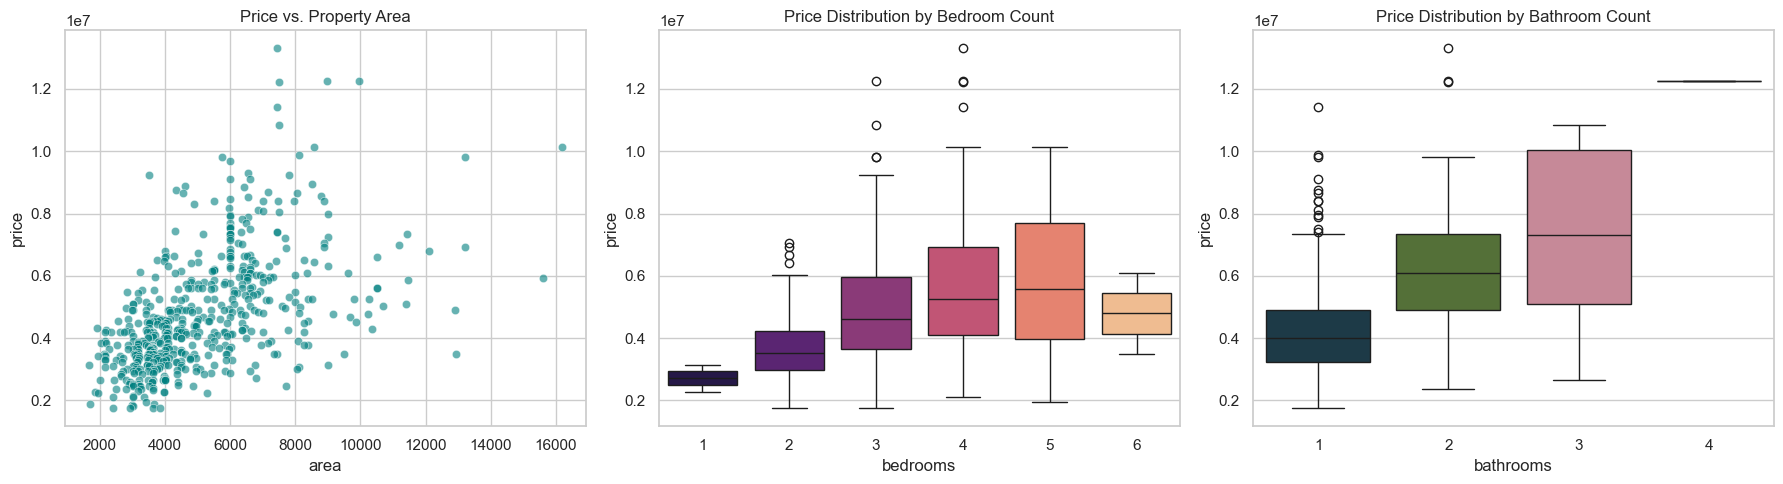

In [ ]:
# HOUSE PRICES BIVARIATE PLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. House Price vs Area
sns.scatterplot(x='area', y='price', data=housing_data, ax=axes[0], color='teal', alpha=0.6)
axes[0].set_title('Price vs. Property Area')

# 2. House Price vs Bedrooms
sns.boxplot(x='bedrooms', y='price', data=housing_data, ax=axes[1], palette='magma')
axes[1].set_title('Price Distribution by Bedroom Count')

# 3. House Price vs Bathrooms
sns.boxplot(x='bathrooms', y='price', data=housing_data, ax=axes[2], palette='cubehelix')
axes[2].set_title('Price Distribution by Bathroom Count')
plt.tight_layout()
plt.show()

These bivariate charts show that property area and the number of bathrooms have a strong, positive influence on house prices, while bedroom count shows a less consistent trend. The scatter plot reveals a clear pattern where house prices steadily rise as the living area increases. Additionally, the box plots demonstrate that adding more bathrooms drives a substantial, sharp jump in property valuation, whereas adding more bedrooms increases the price up to 4 or 5 rooms before dropping off at 6 bedrooms.




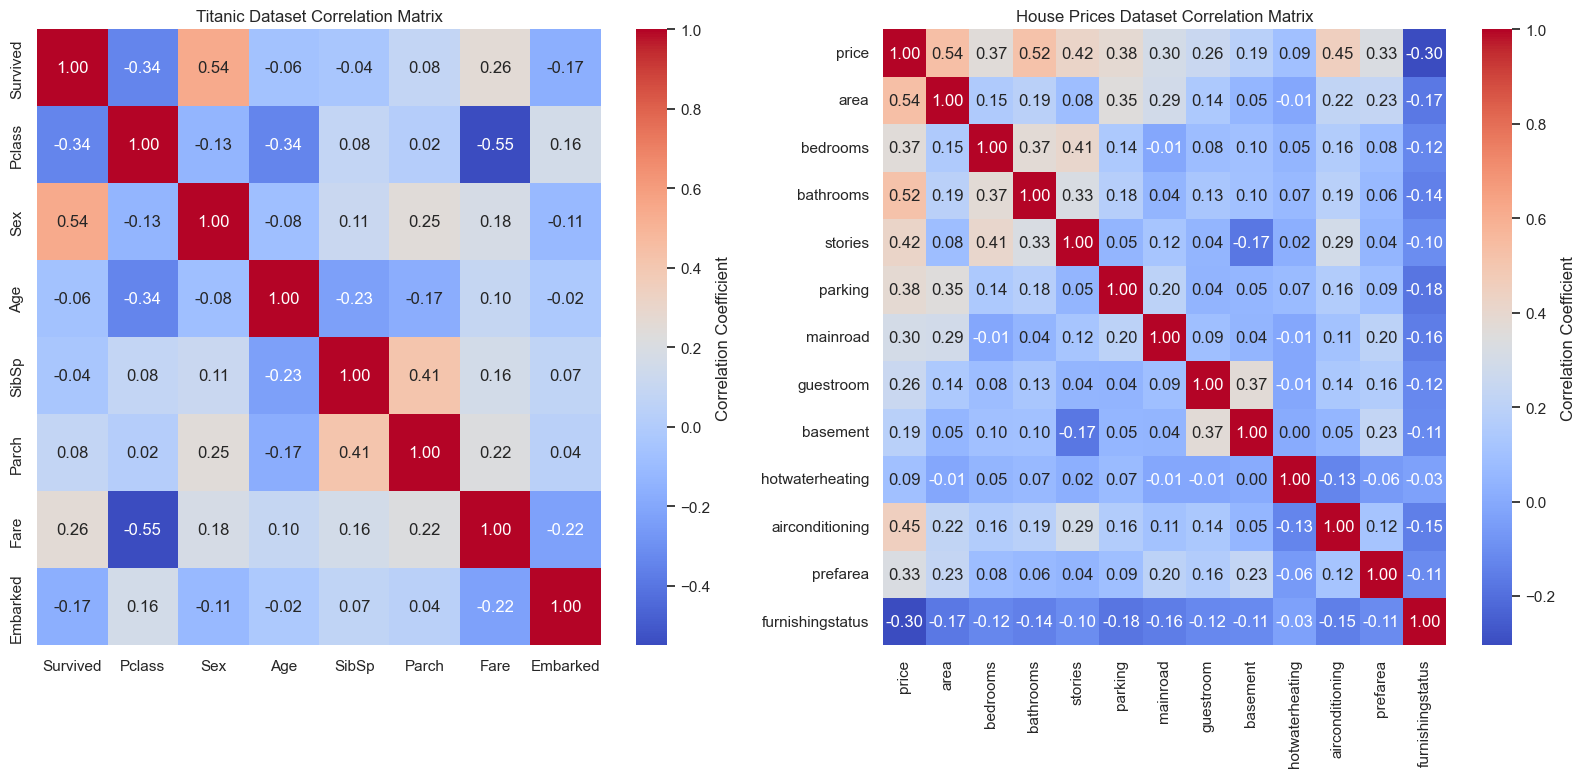

In [ ]:

# TITANIC CORRELATION
# Map categorical values to numeric codes for correlation analysis
titanic_corr_df = titanic_data.copy()
titanic_corr_df['Sex'] = titanic_corr_df['Sex'].map({'male': 0, 'female': 1})
titanic_corr_df['Embarked'] = titanic_corr_df['Embarked'].astype('category').cat.codes

# Calculate numerical correlation matrix
titanic_matrix = titanic_corr_df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].corr()

# HOUSE PRICES CORRELATION
house_corr_df = housing_data.copy()
# Convert binary text features to 0 and 1
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    house_corr_df[col] = house_corr_df[col].map({'yes': 1, 'no': 0})
house_corr_df['furnishingstatus'] = house_corr_df['furnishingstatus'].astype('category').cat.codes

# Calculate numerical correlation matrix
house_matrix = house_corr_df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'] + binary_cols + ['furnishingstatus']].corr()

# --- PLOTTING HEATMAPS ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Titanic Heatmap
sns.heatmap(titanic_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], cbar_kws={'label': 'Correlation Coefficient'})
axes[0].set_title('Titanic Dataset Correlation Matrix')

# House Prices Heatmap
sns.heatmap(house_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], cbar_kws={'label': 'Correlation Coefficient'})
axes[1].set_title('House Prices Dataset Correlation Matrix')

# plt.tight_layout()
plt.show()


The heatmaps reveal that for the Titanic dataset, a passenger's Sex has the strongest positive correlation with survival (r = 0.54), whereas Pclass has a notable negative correlation (r = -0.34), confirming that female and higher-class passengers had vastly superior survival odds. Additionally, Pclass and Fare share a strong inverse relationship (r = -0.55), proving that premium ticket pricing directly corresponds to a higher socioeconomic class. 

For the House Prices dataset, the property's area (r = 0.54) and the number of bathrooms (r = 0.52) emerge as the most critical continuous drivers of house prices, followed closely by airconditioning (r = 0.45) and stories (r = 0.42). Conversely, furnishingstatus exhibits a negative correlation (r = -0.30) with price, meaning unfurnished properties drastically bring down market valuations.

## Part 5: Insights & Recommendations
Here are 5 key analytical insights for each dataset.
### Dataset 1: Titanic Dataset Insights

   1. Strong Gender Disparity: Female passengers had an overwhelmingly higher survival rate compared to males. Gender stands out as the single most dominant statistical split in the data.
   2. Socioeconomic Class Bias: A stark gradient exists across socioeconomic brackets. First-class travelers had significantly better survival rates, while third-class passengers experienced massive mortality rates due to cabin placement or evacuation sorting.
   3. Fare Predictability: Luxury ticket price (Fare) acts as an excellent continuous proxy for passenger class. Higher fares strongly correlate with increased survival odds.
   4. Age Structural Neutrality: While extreme age demographics (children and the elderly) received targeted priority, the core median age distribution remains structurally flat between survivors and non-survivors.
   5. Family Group Impacts: Traveling alone drastically lowered survival chances compared to traveling in small family units. However, overly large family groups ran into logistics bottlenecks during the evacuation.

### Dataset 2: Housing Price Prediction Insights

   1. Physical Dimensions Drive Value: Living space (area) is the strongest continuous driver of real estate pricing. As total square footage scales upward, the baseline property valuation follows a reliable linear trend.
   2. Luxury Infrastructure Premiums: The inclusion of multiple bathrooms acts as a high-end luxury signal, yielding a steeper price escalation than merely adding basic bedrooms.
   3. Vertical Layout Valuation: Multi-story configurations (stories) pull a premium over flat, single-level properties, representing higher urban construction utility.
   4. Premium Utility Features: Secondary infrastructure flags—specifically the presence of airconditioning and dedicated parking spaces—provide a massive valuation boost over properties lacking these additions.
   5. Location Layout Leverage: Homes situated along a mainroad or categorized within a preferred neighborhood zone (prefarea) hold much higher floor values, emphasizing that external accessibility profiles significantly augment internal structural metrics.